In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

import hpcrec

# Helper functions for wave-kinematics reconstruction
from hpcrec.test_cases.wave_kinematics import (
    FreeSurfaceConformingDomain,
    solve_wave_kinematics,
    compute_velocity,
)

# Read HOSM results

Read the wave elevation $\eta(x)$ and velocity potential at the free surface $\psi(x)$ from HOSM (DNV WAMOD)

In [2]:
# These data files are not checked into the Git repo
inputfile = "data/hosm_output.h5"
inputfile = "data/hosm_output_infinite_depth.h5"
time_index = 11755  # the time index to reconstruct wave kinematics for

with h5py.File(inputfile, "r") as f:
    print(f"WAMOD metadata from {inputfile}:")
    for key in ["dkx", "dx", "h", "ndim", "nx", "xdom"]:
        val = f.attrs[key].item()
        print(f"  {key}: {val}")
    for key in ["Hs", "Tp", "Tz"]:
        if key in f.attrs:
            val = f.attrs[key].item()
            print(f"  {key}: {val}")

    dk = f.attrs["dkx"].item()
    L = f.attrs["xdom"].item()
    nx = f.attrs["nx"].item()
    depth = f.attrs["h"].item()

    if depth < 0:
        if "Tp" in f.attrs:
            Tp = f.attrs["Tp"].item()
            depth = 9.81 * Tp**2 / (2 * np.pi)  # deep-water approximation
            print(f"\nUsing deep-water approximation depth = {depth:.3f} m due to Tp = {Tp:.1f} s")

    # Equally spaced x-grid points (peridic domain, endpoint=startpoint)
    xgrid = np.linspace(0, L, nx, endpoint=False)

    # Wave elevation at all x-grid points from WAMOD
    eta = f["spatial_fields"]["eta"][time_index, :].squeeze()

    # Velocity potential at all x-grid points (at z=eta) from WAMOD
    psi = f["spatial_fields"]["psi"][time_index, :].squeeze()

print(f"\nWAMOD eta and psi have shape: {eta.shape}, {psi.shape}")

WAMOD metadata from data/hosm_output_infinite_depth.h5:
  dkx: 7.118676331721985e-05
  dx: 43.09736013842832
  h: -1.0
  ndim: 1
  nx: 2048
  xdom: 88263.3935635012
  Hs: 19.0
  Tp: 18.2
  Tz: -1.0

Using deep-water approximation depth = 517.168 m due to Tp = 18.2 s

WAMOD eta and psi have shape: (2048,), (2048,)


# Reconstruct the wave kinematics using HPC

Create a regular domain where the top boundary conforms to the known wave profile and the lower
layers blend towards the flat bottom bottom layer at z=-depth.

The grid resolution is given by the HOSM solution in the x-direction and we select to have `Nz`
points in the z-direction by computing `Nz` from $\Delta x \approx \Delta y$ at and assuming the
total domain height is the same as the depth, i.e. $\eta$ is not huge compared to $h$.

We can optionally oversample the HOSM solution by including, e.g., four HPC dofs per HOSM value,
setting `Nx_hpc = 4 * Nx_hosm` and similarly in the z-direction. This will lead to lower
reconstruction errors. WAMOD will also by default only write every other x-grid point to the output.

## How to reconstruct the wave kinematics for a single time instance:

* Find $\phi(x, z)$, the velocity potential in the fluid domain, given a known $\eta(x)$, the free
  surface elevation, and $\psi(x)$, the corresponding velocity potential at the free surface.
* We know the position of all boundaries (z=-depth, z=eta, x=0, x=L).
* The solution is periodic in space (x-direction), so tha $\eta(x=0) = \eta(x=L)$ and the same for
  the velocity potential, $\psi(x)$, and our unknown reconstruction $\phi(x,z)$. 
* We know the boundary conditions. Top BC is Dirichlet $\phi(x;\ z=\eta(x)) = \psi(x)$, the left and
  right boundaries are periodic, the bottom has the standard free-slip bottom boundary condition.

When we have found $\phi(x,z)$ then we can find the velocity everywhere in the fluid as $\nabla \phi$

In [3]:
# Oversample the HOSM solution to get a more accurate reconstruction
# The native WAMOD HOSM solution is computed on a finer grid but only
# every other point is stored in the result files by default.
oversample_factor = 4

# Construct deformed wave domain
domain = FreeSurfaceConformingDomain(L, depth, eta, oversample=oversample_factor)

# Print some information about the domain
print(f"Domain depth {domain.depth:.3f}m and length is {domain.length:.3f}m")
print(f"Domain grid shape: {domain.grid_shape}")
print(f"Average grid spacing dx = {domain.length / domain.grid_shape[0]:.3f}m")
print(f"Average grid spacing dz = {domain.depth / domain.grid_shape[1]:.3f}m")
print(f"The HPC domain has {len(domain.dof_coordinates):_d} DOFs")

Domain depth 517.168m and length is 88263.394m
Domain grid shape: (8192, 48)
Average grid spacing dx = 10.774m
Average grid spacing dz = 10.774m
The HPC domain has 401_408 DOFs


In [4]:
# Find the highest wave crest in the input WAMOD data
i_crest0 = int(np.argmax(eta))
x_crest0 = xgrid[i_crest0]
z_crest0 = float(eta[i_crest0])
print(f"Highest HOSM crest   : eta = {z_crest0:.3f} m at x = {x_crest0:.1f} m")

# Same crest, in the oversampled HPC domain
assert domain.grid_shape is not None, "Domain grid shape is not set!?"
Nx_g, Nz_g = domain.grid_shape
i_crest1 = i_crest0 * oversample_factor
dofs_crest_column = domain.column_dofs(i=i_crest1)
dof_crest1 = dofs_crest_column[-1]
x_crest1 = domain.dof_coordinates[dof_crest1, 0]
z_crest1 = domain.dof_coordinates[dof_crest1, 1]
print(f"Same crest HPC domain: eta = {z_crest1:.3f} m at x = {x_crest1:.1f} m")

# Highest wave crest in the HPC domain
# (may be slightly different than the WAMOD crest due to oversampling)
i_crest1_hpc = int(np.argmax(domain.z_fs))
x_crest1_hpc = domain.x_fs[i_crest1_hpc]
z_crest1_hpc = domain.z_fs[i_crest1_hpc]
print(f"Highest HPC  crest   : eta = {z_crest1_hpc:.3f} m at x = {x_crest1_hpc:.1f} m")

Highest HOSM crest   : eta = 30.335 m at x = 88091.0 m
Same crest HPC domain: eta = 30.335 m at x = 88091.0 m
Highest HPC  crest   : eta = 33.519 m at x = 88101.8 m


In [5]:
# Solve for the velocity potential at all DOFs in the domain
with hpcrec.Timer("Reconstructing velocity potential"):
    phi = solve_wave_kinematics(domain, psi, oversample=oversample_factor)

STARTING Reconstructing velocity potential
DONE with Reconstructing velocity potential in 2.4014 seconds


# Inspect the reconstructed solution

In [6]:
# The HPC horizontal velocity at the crest based on the reconstructed velocity potential phi
vels = compute_velocity(domain, phi, [dof_crest1])
u_at_crest_hpc = vels[0][0]
w_at_crest_hpc = vels[1][0]
print(f"HPC  u = d(phi_hpc)/dx               at crest: u = {u_at_crest_hpc:6.3f} m/s")
print(f"HPC  w = d(phi_hpc)/dz               at crest: w = {w_at_crest_hpc:6.3f} m/s\n")

# The HOSM horizontal velocity at the crest based on the HOSM velocity potential psi
k_angular = 2 * np.pi * np.fft.fftfreq(int(nx), d=L / nx)
psi_x = np.fft.ifft(1j * k_angular * np.fft.fft(psi)).real  # dpsi/dx at surface
eta_x = np.fft.ifft(1j * k_angular * np.fft.fft(eta)).real  # deta/dx
w_at_crest_hosm = 0.0  # Should be approximately zero at the crest?
u_at_crest_hosm1 = psi_x[i_crest0] - w_at_crest_hosm * eta_x[i_crest0]
u_at_crest_hosm2 = psi_x[i_crest0] - w_at_crest_hpc * eta_x[i_crest0]
print(f"HOSM u = d(psi)/dx - 0.000*d(eta)/dx at crest: u = {u_at_crest_hosm1:6.3f} m/s")
print(f"HOSM u = d(psi)/dx - w_hpc*d(eta)/dx at crest: u = {u_at_crest_hosm2:6.3f} m/s\n")

diff1 = u_at_crest_hosm1 - u_at_crest_hpc
diff2 = u_at_crest_hosm2 - u_at_crest_hpc
print(f"Diff 1 {diff1:10.6f} which gives relative error {diff1 / u_at_crest_hpc:8.3%}")
print(f"Diff 2 {diff2:10.6f} which gives relative error {diff2 / u_at_crest_hpc:8.3%}")

HPC  u = d(phi_hpc)/dx               at crest: u = 15.403 m/s
HPC  w = d(phi_hpc)/dz               at crest: w = -1.550 m/s

HOSM u = d(psi)/dx - 0.000*d(eta)/dx at crest: u = 14.668 m/s
HOSM u = d(psi)/dx - w_hpc*d(eta)/dx at crest: u = 15.343 m/s

Diff 1  -0.735178 which gives relative error  -4.773%
Diff 2  -0.059338 which gives relative error  -0.385%


# Plot the reconstructed solution

In [7]:
show_mesh = False
show_velocity = True

if show_velocity:
    with hpcrec.Timer("Computing the velocity for all DOFs"):
        u_hpc, v_hpc = compute_velocity(domain, phi)

STARTING Computing the velocity for all DOFs
DONE with Computing the velocity for all DOFs in 0.0456 seconds


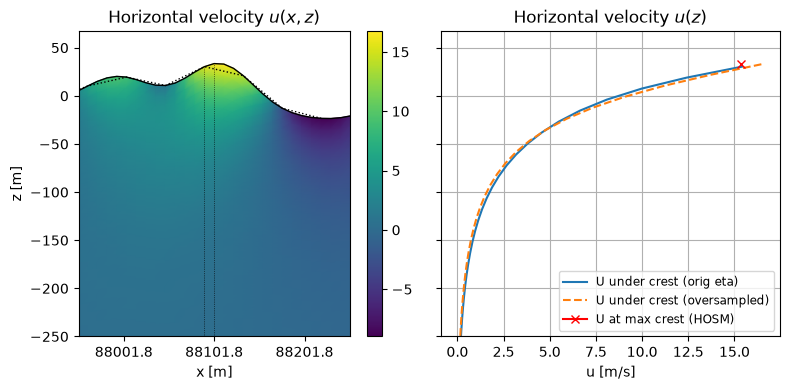

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
axp, axu = axs

# Plot the horizontal velocity u or the velocity potential phi
if show_velocity:
    axp.set_title("Horizontal velocity $u(x,z)$")
    hpcrec.plot(domain, u_hpc, ax=axp)
else:
    axp.set_title("Velocity potential $\\phi(x,z)$")
    hpcrec.plot(domain, phi, ax=axp)

# Show the grid mesh if requested
# (this shows the plot triangles, not the HPC quadrilaterals!)
if show_mesh:
    hpcrec.plot(domain, ax=axp)

# Show the wave elevation eta in the plot
axp.plot(xgrid, eta, "k:", lw=1, label="Wave elevation $\\eta$ (original)")
axp.plot(domain.x_fs, domain.z_fs, "k-", lw=1, label="Wave elevation $\\eta$ (oversampled)")

# Show the crest location in the plot
for x_crest, z_crest in [(x_crest1, z_crest1), (x_crest1_hpc, z_crest1_hpc)]:
    axp.plot([x_crest, x_crest], [-domain.depth, z_crest], "k:", lw=0.5)

axp.set_xlim(x_crest1_hpc - 150, x_crest1_hpc + 150)
axp.set_xticks([x_crest1_hpc - 100, x_crest1_hpc, x_crest1_hpc + 100])
axp.set_ylim(-250, 2 * z_crest1_hpc)
axp.set_xlabel("x [m]")
axp.set_ylabel("z [m]")

# Plot the horizontal velocity u underneath the crest
axu.set_title("Horizontal velocity $u(z)$")
for column_dofs, label in [
    (domain.column_dofs(x=x_crest1), "U under crest (orig eta)"),
    (domain.column_dofs(x=x_crest1_hpc), "U under crest (oversampled)"),
]:
    u_col, w_col = compute_velocity(domain, phi, dofs=column_dofs)
    z_col = domain.dof_coordinates[column_dofs, 1]
    axu.plot(u_col, z_col, label=label, ls="--" if "oversampled" in label else "-")
axu.plot(u_at_crest_hosm2, z_crest1_hpc, marker="x", color="r", label="U at max crest (HOSM)")
axu.legend(loc="lower right", fontsize="small")
axu.grid(True)
axu.set_xlabel("u [m/s]")

fig.tight_layout()